In [1]:
import keras, tensorflow as tf
from sklearn.model_selection import train_test_split

keras.utils.set_random_seed(42)
tf.random.set_seed(42)
tf.config.experimental.enable_op_determinism()

(train_input, train_target), _ = \
    keras.datasets.fashion_mnist.load_data()
train_scaled = train_input / 255.0
train_scaled, val_scaled, train_target, val_target = \
    train_test_split(train_scaled, train_target,
                     test_size=0.2, random_state=42)
def model_fn(a_layer=None):
    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(28, 28)))
    model.add(keras.layers.Flatten())
    model.add(keras.layers.Dense(100, activation='relu'))
    if a_layer:
        model.add(a_layer)   # 은닉층 후, 출력층 전
    model.add(keras.layers.Dense(10, activation='softmax'))
    return model

model_fn()                           # 기본 2층
model_fn(keras.layers.Dropout(0.3)) # Dropout 포함

<Sequential name=sequential_1, built=True>

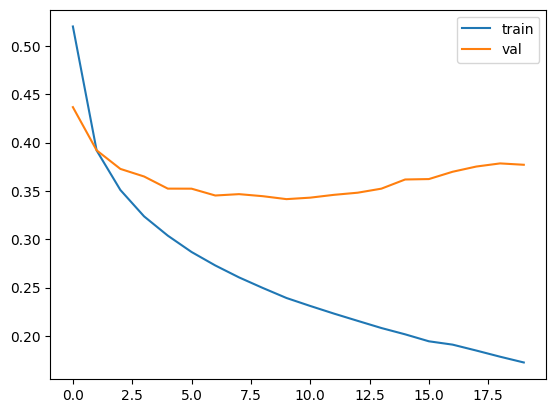

In [3]:
from matplotlib import pyplot as plt


model = model_fn()
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
history = model.fit(
    train_scaled, train_target, epochs=20, verbose=0,
    validation_data=(val_scaled, val_target))

plt.plot(history.history['loss'],     label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend(); plt.show()

In [4]:
model = model_fn(keras.layers.Dropout(0.3))
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
history = model.fit(
    train_scaled, train_target, epochs=20, verbose=0,
    validation_data=(val_scaled, val_target))

In [5]:
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    'best-model.keras',
    save_best_only=True)   # val_loss 개선될 때만 저장

early_stopping_cb = keras.callbacks.EarlyStopping(
    patience=2,                  # 2 epoch 개선 없으면 종료
    restore_best_weights=True)   # 최적 가중치 복원

history = model.fit(
    train_scaled, train_target, epochs=20, verbose=0,
    validation_data=(val_scaled, val_target),
    callbacks=[checkpoint_cb, early_stopping_cb])

print(early_stopping_cb.stopped_epoch)  # 12
model.evaluate(val_scaled, val_target)  # 0.8853

4
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 940us/step - accuracy: 0.8888 - loss: 0.3204


[0.3203580975532532, 0.8887500166893005]